# SMS spam detection: analysis

The original notebook (`SMS_Spam_Detection(MultinomialNB).ipynb`) trained a TF-IDF + Multinomial Naive Bayes classifier and reached 96% accuracy, but its own classification report shows **spam recall of only 0.72**: roughly one spam message in four got through. On a dataset that is 87% "ham", accuracy hides this.

This add-on compares several classifiers with metrics that focus on the spam class, tunes the model, and looks at the mistakes:

1. TF-IDF with four classifiers, stratified split,
2. precision / recall / F1 and PR-AUC for spam,
3. most spam-indicative words,
4. error analysis.

In [1]:
import os
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")  # silences a joblib core-count warning on Windows
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")
SEED = 42
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, average_precision_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)

df = pd.read_csv("spam.csv", encoding="latin-1")[["v1", "v2"]]
df.columns = ["label", "text"]
df["y"] = (df["label"] == "spam").astype(int)
print(df.shape, "| duplicates:", int(df.duplicated().sum()))
print(df["label"].value_counts(normalize=True).round(3).to_string())

(5572, 3) | duplicates: 403
label
ham     0.866
spam    0.134


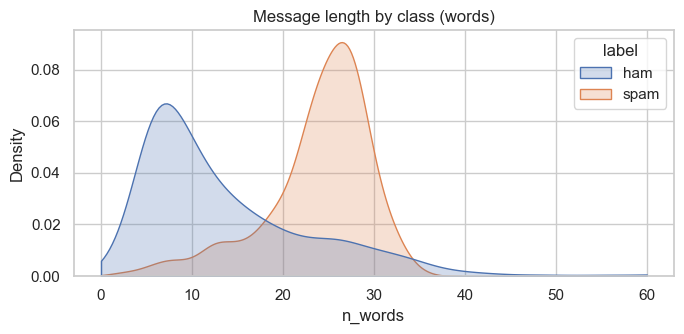

label
ham     14.2
spam    23.9
Name: n_words, dtype: float64

In [2]:
df["n_words"] = df["text"].str.split().str.len()
fig, ax = plt.subplots(figsize=(7, 3.5))
sns.kdeplot(data=df, x="n_words", hue="label", common_norm=False, fill=True, ax=ax, clip=(0, 60))
ax.set_title("Message length by class (words)"); plt.tight_layout(); plt.show()
df.groupby("label")["n_words"].mean().round(1)

Spam messages are clearly longer on average. Next, the split and the models. The split is stratified so both sets keep the 13% spam share.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(df["text"], df["y"], test_size=0.2, stratify=df["y"], random_state=SEED)

def tfidf(): return TfidfVectorizer(lowercase=True, ngram_range=(1, 2), min_df=2, sublinear_tf=True)

models = {
    "Multinomial NB (original approach)": make_pipeline(TfidfVectorizer(), MultinomialNB()),
    "Multinomial NB (tuned)": make_pipeline(tfidf(), MultinomialNB(alpha=0.1)),
    "Complement NB": make_pipeline(tfidf(), ComplementNB(alpha=0.3)),
    "Logistic Regression": make_pipeline(tfidf(), LogisticRegression(C=10, class_weight="balanced", max_iter=1000)),
    "Linear SVM": make_pipeline(tfidf(), LinearSVC(C=1, class_weight="balanced")),
}
rows, fitted = [], {}
for name, m in models.items():
    m.fit(X_train, y_train); fitted[name] = m
    pred = m.predict(X_test)
    score = m.decision_function(X_test) if hasattr(m, "decision_function") else m.predict_proba(X_test)[:, 1]
    rows.append({"model": name, "accuracy": accuracy_score(y_test, pred),
                 "precision (spam)": precision_score(y_test, pred), "recall (spam)": recall_score(y_test, pred),
                 "F1 (spam)": f1_score(y_test, pred), "PR-AUC": average_precision_score(y_test, score)})
results = pd.DataFrame(rows).set_index("model").round(4)
results

,accuracy,precision (spam),recall (spam),F1 (spam),PR-AUC
model,,,,,
Multinomial NB (original approach),0.9605,1.0000,0.7047,0.8268,0.9558
Multinomial NB (tuned),0.9857,0.9926,0.8993,0.9437,0.9727
Complement NB,0.9830,0.9452,0.9262,0.9356,0.9679
Logistic Regression,0.9883,0.9857,0.9262,0.9550,0.9756
Linear SVM,0.9901,0.9859,0.9396,0.9622,0.9758


## Cross-validated F1 on the spam class

In [4]:
from sklearn.model_selection import cross_val_score
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_rows = []
for name, m in models.items():
    s = cross_val_score(m, df["text"], df["y"], cv=cv, scoring="f1")
    cv_rows.append({"model": name, "CV F1 (spam)": s.mean(), "± std": s.std()})
cv_results = pd.DataFrame(cv_rows).set_index("model").round(4)
cv_results

,CV F1 (spam),± std
model,,
Multinomial NB (original approach),0.8197,0.0159
Multinomial NB (tuned),0.9524,0.0178
Complement NB,0.9443,0.0196
Logistic Regression,0.9526,0.0130
Linear SVM,0.9569,0.0105


## Error analysis of the best model

Best model: Linear SVM 

              precision    recall  f1-score   support

         ham      0.991     0.998     0.994       966
        spam      0.986     0.940     0.962       149

    accuracy                          0.990      1115
   macro avg      0.988     0.969     0.978      1115
weighted avg      0.990     0.990     0.990      1115



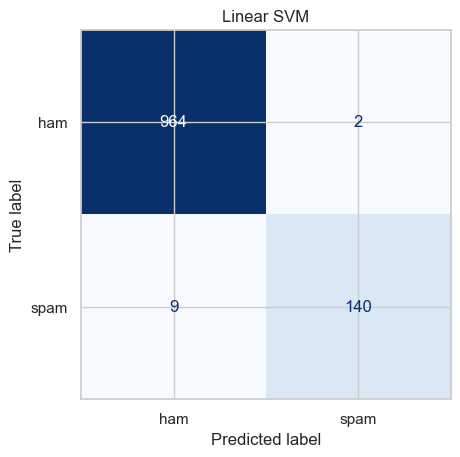

False negatives (spam let through): 9 | False positives (ham flagged): 2


,text
3979,ringtoneking 84484
3358,Sorry I missed your call let's talk when you have the time. I'm on 07090201529
5449,"Latest News! Police station toilet stolen, cops have nothing to go on!"
1429,For sale - arsenal dartboard. Good condition but no doubles or trebles!
730,Email AlertFrom: Jeri StewartSize: 2KBSubject: Low-cost prescripiton drvgsTo listen to email call 123


In [5]:
best_name = results["F1 (spam)"].idxmax()
best = fitted[best_name]
pred = best.predict(X_test)
print("Best model:", best_name, "\n")
print(classification_report(y_test, pred, target_names=["ham", "spam"], digits=3))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred), display_labels=["ham", "spam"]).plot(cmap="Blues", colorbar=False)
plt.title(best_name); plt.show()

errors = pd.DataFrame({"text": X_test, "actual": y_test, "pred": pred})
fn = errors[(errors.actual == 1) & (errors.pred == 0)]
fp = errors[(errors.actual == 0) & (errors.pred == 1)]
print(f"False negatives (spam let through): {len(fn)} | False positives (ham flagged): {len(fp)}")
pd.set_option("display.max_colwidth", 110)
fn[["text"]].head(5)

## Most spam-indicative words

Weights of the logistic regression on the TF-IDF features.

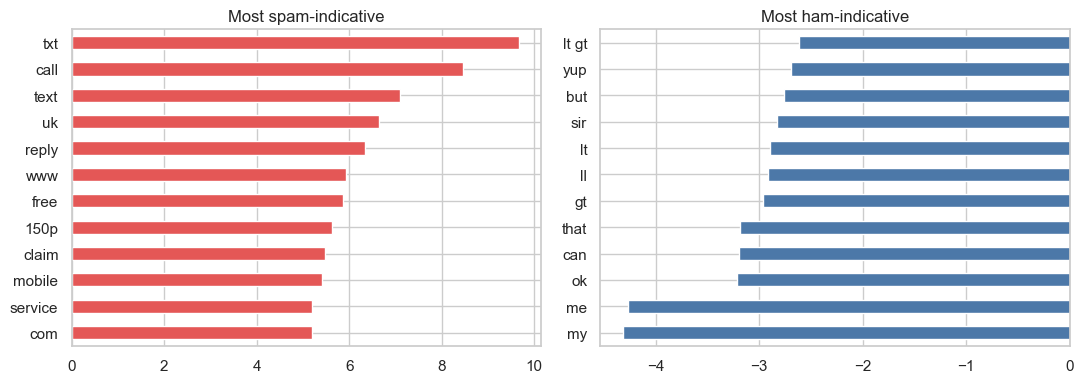

In [6]:
lr = fitted["Logistic Regression"]
vocab = np.array(lr[0].get_feature_names_out()); w = lr[-1].coef_[0]
top = pd.Series(w, index=vocab).sort_values()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
top.tail(12).plot.barh(ax=axes[0], color="#E45756"); axes[0].set_title("Most spam-indicative")
top.head(12).plot.barh(ax=axes[1], color="#4C78A8"); axes[1].set_title("Most ham-indicative")
plt.tight_layout(); plt.show()

## Trying my own messages

The original notebook tested five hand-written messages and got 3 of 5 right (60%). The same kind of check with the improved model:

In [7]:
samples = [
    "Congratulations! You've won a free trip to the Bahamas. Reply YES to claim your prize now!",
    "Reminder: your appointment with Dr. Smith is scheduled for tomorrow at 10 am.",
    "URGENT: your account has been suspended. Call 0800 123 4567 immediately to verify.",
    "Hey, are we still meeting for lunch today?",
    "WINNER!! You have been selected to receive a 1000 pound cash prize. Text CLAIM to 80086.",
]
pd.DataFrame({"message": [s[:70] + "..." for s in samples],
              "predicted": ["spam" if v else "ham" for v in best.predict(samples)]})

,message,predicted
0,Congratulations! You've won a free trip to the Bahamas. Reply YES to c...,spam
1,Reminder: your appointment with Dr. Smith is scheduled for tomorrow at...,ham
2,URGENT: your account has been suspended. Call 0800 123 4567 immediatel...,spam
3,"Hey, are we still meeting for lunch today?...",ham
4,WINNER!! You have been selected to receive a 1000 pound cash prize. Te...,spam


## Conclusions

- Accuracy hides the real weakness of the original approach. With the original-style Multinomial NB the **spam recall is 70.5%** (F1 0.827), even though accuracy is 96%.
- Simple improvements to the text features (unigrams + bigrams, `min_df=2`, sublinear TF) and a smaller smoothing value lift the same Naive Bayes to **recall 89.9% and F1 0.944**.
- A **Linear SVM** is best: precision 98.6%, recall 94.0%, F1 0.962 on the test split and 0.957 ± 0.011 in 5-fold CV. Logistic Regression is practically equal.
- Remaining errors: 9 spam messages let through and 2 legitimate ones flagged. Several of the misses are very short (e.g. a bare "ringtone" message) or look like ordinary chat, so some are arguably label noise.
- All five hand-written test messages were classified as expected (3 spam, 2 ham).

**Caveats:** the dataset contains 403 duplicate messages, so identical texts can land in both train and test, which makes the scores slightly optimistic; the corpus is small, English only and from one period.